In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
trader_df = pd.read_csv("historical_data.csv")
sentiment_df = pd.read_csv("fear_greed_index.csv")

In [3]:
trader_df.head()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,5.201771e+10,True,0.345404,8.950000e+14,1.730000e+12
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,5.201771e+10,True,0.005600,4.430000e+14,1.730000e+12
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,5.201771e+10,True,0.050431,6.600000e+14,1.730000e+12
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,5.201771e+10,True,0.050043,1.080000e+15,1.730000e+12
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,5.201771e+10,True,0.003055,1.050000e+15,1.730000e+12


In [4]:
sentiment_df.head()

,timestamp,value,classification,date
0,1517463000,30,Fear,2018-02-01
1,1517549400,15,Extreme Fear,2018-02-02
2,1517635800,40,Fear,2018-02-03
3,1517722200,24,Extreme Fear,2018-02-04
4,1517808600,11,Extreme Fear,2018-02-05


In [5]:
print(trader_df.shape)
print(sentiment_df.shape)

(18608, 16)
(2644, 4)


In [6]:
trader_df.columns

Index(['Account', 'Coin', 'Execution Price', 'Size Tokens', 'Size USD', 'Side',
       'Timestamp IST', 'Start Position', 'Direction', 'Closed PnL',
       'Transaction Hash', 'Order ID', 'Crossed', 'Fee', 'Trade ID',
       'Timestamp'],
      dtype='object')

In [7]:
sentiment_df.columns

Index(['timestamp', 'value', 'classification', 'date'], dtype='object')

In [8]:
trader_df.isnull().sum()

,0
Account,0
Coin,0
Execution Price,0
Size Tokens,0
Size USD,0
Side,0
Timestamp IST,0
Start Position,0
Direction,0
Closed PnL,1


In [9]:
sentiment_df.isnull().sum()

,0
timestamp,0
value,0
classification,0
date,0


In [10]:
print(trader_df.duplicated().sum())

0


In [11]:
print(sentiment_df.duplicated().sum())

0


In [12]:
trader_df = trader_df.drop_duplicates()
sentiment_df = sentiment_df.drop_duplicates()

In [15]:
trader_df.head()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,5.201771e+10,True,0.345404,8.950000e+14,1.730000e+12
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,5.201771e+10,True,0.005600,4.430000e+14,1.730000e+12
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,5.201771e+10,True,0.050431,6.600000e+14,1.730000e+12
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,5.201771e+10,True,0.050043,1.080000e+15,1.730000e+12
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,5.201771e+10,True,0.003055,1.050000e+15,1.730000e+12


In [17]:
trader_df['date'] = pd.to_datetime(trader_df['Timestamp IST'], format='%d-%m-%Y %H:%M').dt.date

In [18]:
sentiment_df['date'] = pd.to_datetime(sentiment_df['date']).dt.date

In [19]:
merged_df = pd.merge(
    trader_df,
    sentiment_df[['date', 'classification']],
    on='date',
    how='left'
)

In [20]:
merged_df.head()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp,date,classification
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,5.201771e+10,True,0.345404,8.950000e+14,1.730000e+12,2024-12-02,Extreme Greed
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,5.201771e+10,True,0.005600,4.430000e+14,1.730000e+12,2024-12-02,Extreme Greed
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,5.201771e+10,True,0.050431,6.600000e+14,1.730000e+12,2024-12-02,Extreme Greed
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,5.201771e+10,True,0.050043,1.080000e+15,1.730000e+12,2024-12-02,Extreme Greed
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,5.201771e+10,True,0.003055,1.050000e+15,1.730000e+12,2024-12-02,Extreme Greed


In [21]:
daily_pnl = merged_df.groupby(
    ['date', 'Account']
)['Closed PnL'].sum().reset_index()

In [22]:
daily_pnl.head()

,date,Account,Closed PnL
0,2024-04-20,0x430f09841d65beb3f27765503d0f850b8bce7713,0.000000
1,2024-04-25,0x430f09841d65beb3f27765503d0f850b8bce7713,0.000000
2,2024-06-19,0x430f09841d65beb3f27765503d0f850b8bce7713,0.000000
3,2024-06-20,0x430f09841d65beb3f27765503d0f850b8bce7713,57478.456026
4,2024-07-23,0x430f09841d65beb3f27765503d0f850b8bce7713,88084.992348


In [23]:
sentiment_pnl = merged_df.groupby(
    'classification'
)['Closed PnL'].mean().sort_values()

print(sentiment_pnl)

classification
Extreme Greed     65.938570
Greed            136.216495
Neutral          178.839679
Fear             194.770442
Extreme Fear     338.916162
Name: Closed PnL, dtype: float64


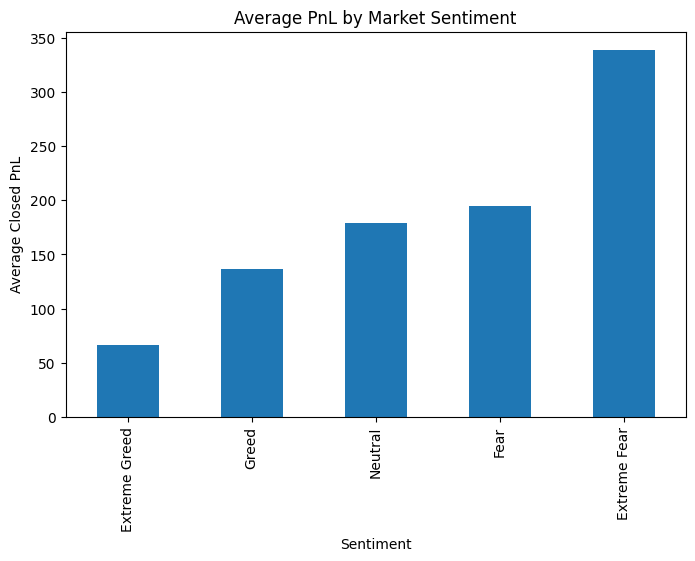

In [24]:
sentiment_pnl.plot(
    kind='bar',
    figsize=(8,5)
)

plt.title("Average PnL by Market Sentiment")
plt.ylabel("Average Closed PnL")
plt.xlabel("Sentiment")
plt.show()

In [25]:
merged_df['win'] = merged_df['Closed PnL'].apply(
    lambda x: 1 if x > 0 else 0
)

In [26]:
win_rate = merged_df.groupby(
    'classification'
)['win'].mean()

print(win_rate)

classification
Extreme Fear     0.322624
Extreme Greed    0.115000
Fear             0.415617
Greed            0.350380
Neutral          0.542618
Name: win, dtype: float64


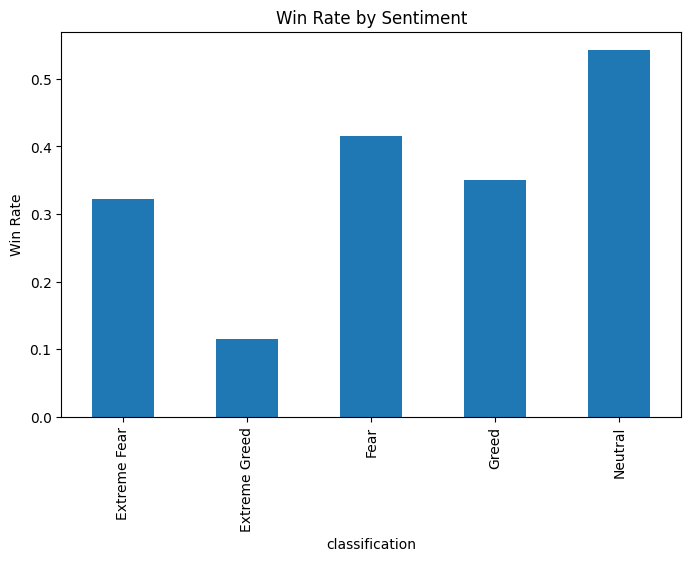

In [27]:
win_rate.plot(
    kind='bar',
    figsize=(8,5)
)

plt.title("Win Rate by Sentiment")
plt.ylabel("Win Rate")
plt.show()

In [28]:
trade_freq = merged_df.groupby(
    'classification'
).size()

print(trade_freq)

classification
Extreme Fear      747
Extreme Greed    1600
Fear             8414
Greed            4732
Neutral          3109
dtype: int64


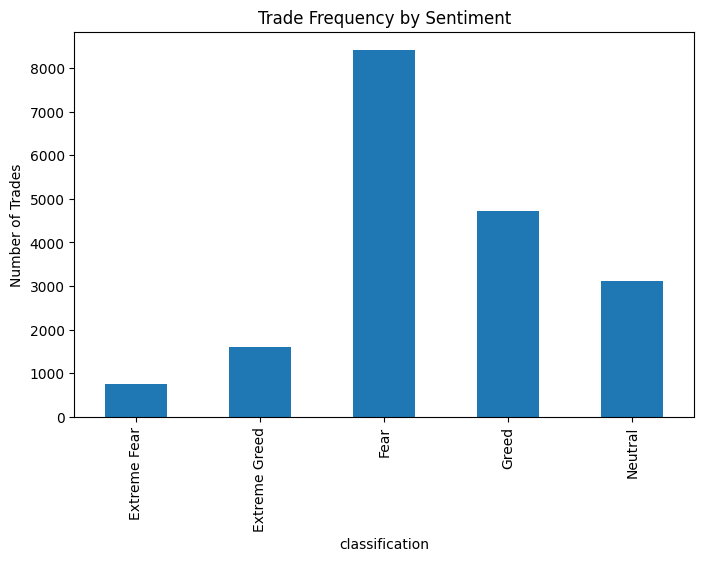

In [29]:
trade_freq.plot(
    kind='bar',
    figsize=(8,5)
)

plt.title("Trade Frequency by Sentiment")
plt.ylabel("Number of Trades")
plt.show()

In [30]:
avg_trade_size = merged_df.groupby(
    'classification'
)['Size USD'].mean()

print(avg_trade_size)

classification
Extreme Fear      7681.766118
Extreme Greed     8437.322281
Fear             30507.735890
Greed            28036.998658
Neutral          25814.644156
Name: Size USD, dtype: float64


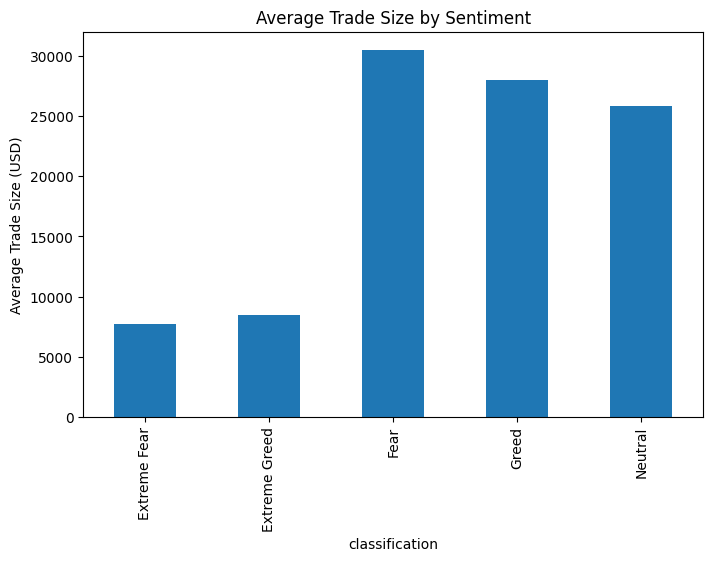

In [31]:
avg_trade_size.plot(
    kind='bar',
    figsize=(8,5)
)

plt.title("Average Trade Size by Sentiment")
plt.ylabel("Average Trade Size (USD)")
plt.show()

In [32]:
merged_df['Side'].value_counts()

,count
Side,
SELL,9335
BUY,9273


In [33]:
long_short = pd.crosstab(
    merged_df['classification'],
    merged_df['Side']
)

print(long_short)

Side             BUY  SELL
classification            
Extreme Fear     441   306
Extreme Greed    569  1031
Fear            4514  3900
Greed           2325  2407
Neutral         1418  1691


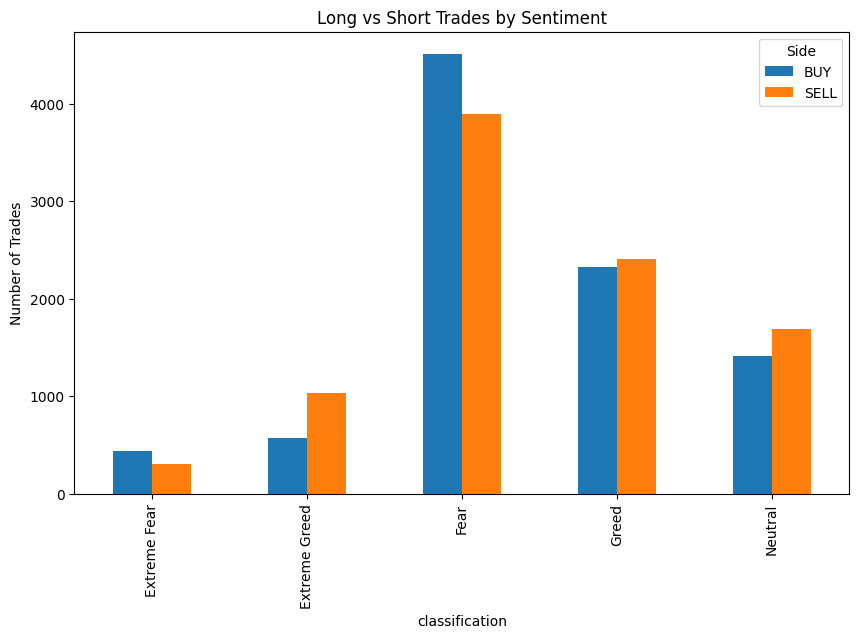

In [34]:
long_short.plot(
    kind='bar',
    figsize=(10,6)
)

plt.title("Long vs Short Trades by Sentiment")
plt.ylabel("Number of Trades")
plt.show()

In [35]:
merged_df.columns

Index(['Account', 'Coin', 'Execution Price', 'Size Tokens', 'Size USD', 'Side',
       'Timestamp IST', 'Start Position', 'Direction', 'Closed PnL',
       'Transaction Hash', 'Order ID', 'Crossed', 'Fee', 'Trade ID',
       'Timestamp', 'date', 'classification', 'win'],
      dtype='object')

In [37]:
risk_analysis = merged_df.groupby(
    'classification'
)['Size USD'].mean()

print(risk_analysis)

classification
Extreme Fear      7681.766118
Extreme Greed     8437.322281
Fear             30507.735890
Greed            28036.998658
Neutral          25814.644156
Name: Size USD, dtype: float64


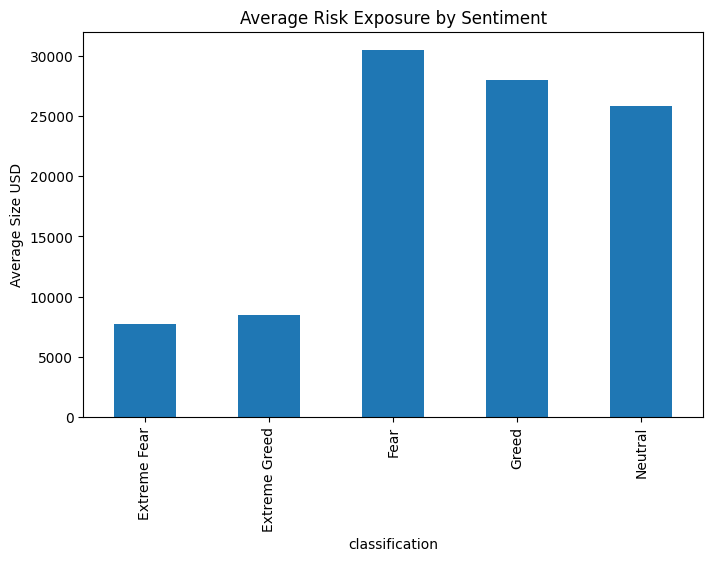

In [38]:
risk_analysis.plot(
    kind='bar',
    figsize=(8,5)
)

plt.title("Average Risk Exposure by Sentiment")
plt.ylabel("Average Size USD")
plt.show()

In [39]:
trader_activity = merged_df.groupby(
    'Account'
).size().reset_index(name='trade_count')

In [40]:
trader_activity.head()

,Account,trade_count
0,0x083384f897ee0f19899168e3b1bec365f52a9012,3818
1,0x430f09841d65beb3f27765503d0f850b8bce7713,561
2,0x513b8629fe877bb581bf244e326a047b249c4ff1,12236
3,0x72c6a4624e1dffa724e6d00d64ceae698af892a0,1430
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,563


In [41]:
trader_activity['segment'] = pd.qcut(
    trader_activity['trade_count'],
    q=3,
    labels=[
        'Low Frequency',
        'Medium Frequency',
        'High Frequency'
    ]
)

In [42]:
trader_activity.head()

,Account,trade_count,segment
0,0x083384f897ee0f19899168e3b1bec365f52a9012,3818,High Frequency
1,0x430f09841d65beb3f27765503d0f850b8bce7713,561,Low Frequency
2,0x513b8629fe877bb581bf244e326a047b249c4ff1,12236,High Frequency
3,0x72c6a4624e1dffa724e6d00d64ceae698af892a0,1430,Medium Frequency
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,563,Low Frequency


In [43]:
trader_win_rate = merged_df.groupby(
    'Account'
)['win'].mean().reset_index()

In [44]:
segment_analysis = pd.merge(
    trader_activity,
    trader_win_rate,
    on='Account'
)

In [45]:
segment_summary = segment_analysis.groupby(
    'segment'
)['win'].mean()

print(segment_summary)

segment
Low Frequency       0.492142
Medium Frequency    0.306294
High Frequency      0.380403
Name: win, dtype: float64


/tmp/ipykernel_1403/4040600211.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  segment_summary = segment_analysis.groupby(


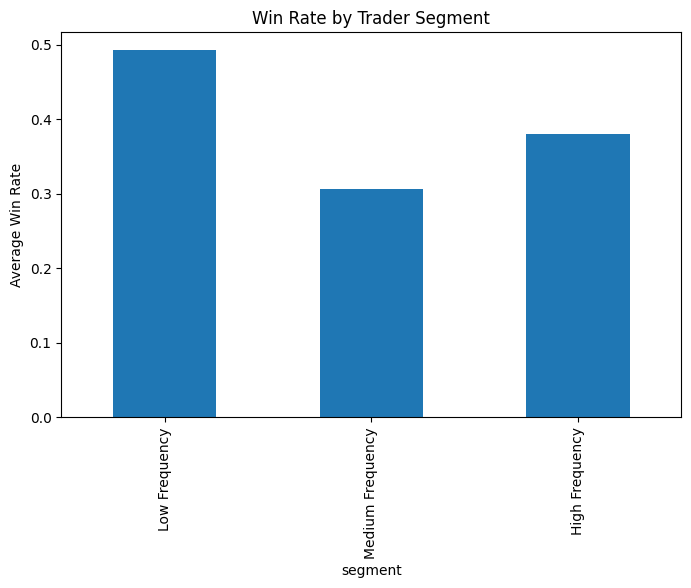

In [46]:
segment_summary.plot(
    kind='bar',
    figsize=(8,5)
)

plt.title("Win Rate by Trader Segment")
plt.ylabel("Average Win Rate")
plt.show()

In [47]:
trader_pnl = merged_df.groupby(
    'Account'
)['Closed PnL'].sum().reset_index()

In [48]:
top_traders = trader_pnl.sort_values(
    by='Closed PnL',
    ascending=False
)

print(top_traders.head(10))

                                      Account    Closed PnL
0  0x083384f897ee0f19899168e3b1bec365f52a9012  1.600230e+06
2  0x513b8629fe877bb581bf244e326a047b249c4ff1  8.404226e+05
3  0x72c6a4624e1dffa724e6d00d64ceae698af892a0  4.030115e+05
1  0x430f09841d65beb3f27765503d0f850b8bce7713  3.288433e+05
4  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  6.784562e+04


In [49]:
print(top_traders.tail(10))

                                      Account    Closed PnL
0  0x083384f897ee0f19899168e3b1bec365f52a9012  1.600230e+06
2  0x513b8629fe877bb581bf244e326a047b249c4ff1  8.404226e+05
3  0x72c6a4624e1dffa724e6d00d64ceae698af892a0  4.030115e+05
1  0x430f09841d65beb3f27765503d0f850b8bce7713  3.288433e+05
4  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  6.784562e+04


In [50]:
daily_trades = merged_df.groupby(
    'date'
).size()

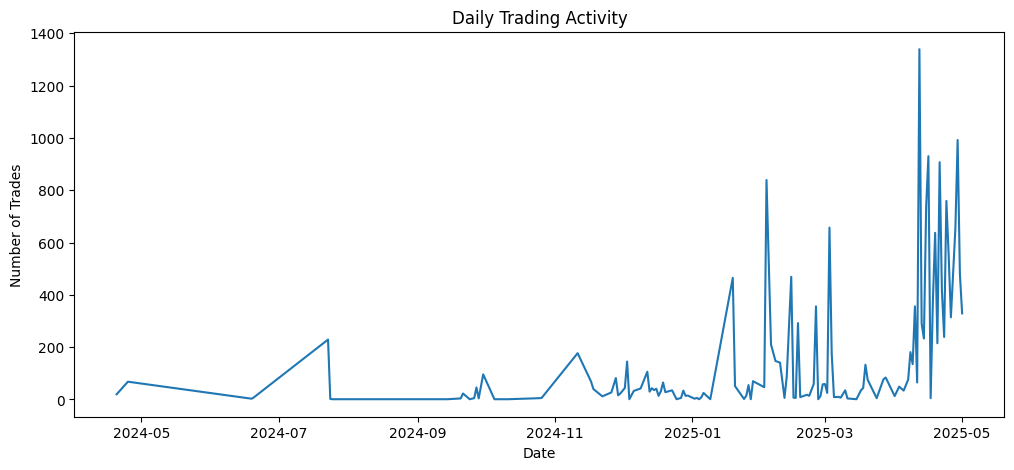

In [51]:
daily_trades.plot(
    figsize=(12,5)
)

plt.title("Daily Trading Activity")
plt.ylabel("Number of Trades")
plt.xlabel("Date")
plt.show()

In [52]:
daily_profit = merged_df.groupby(
    'date'
)['Closed PnL'].sum()

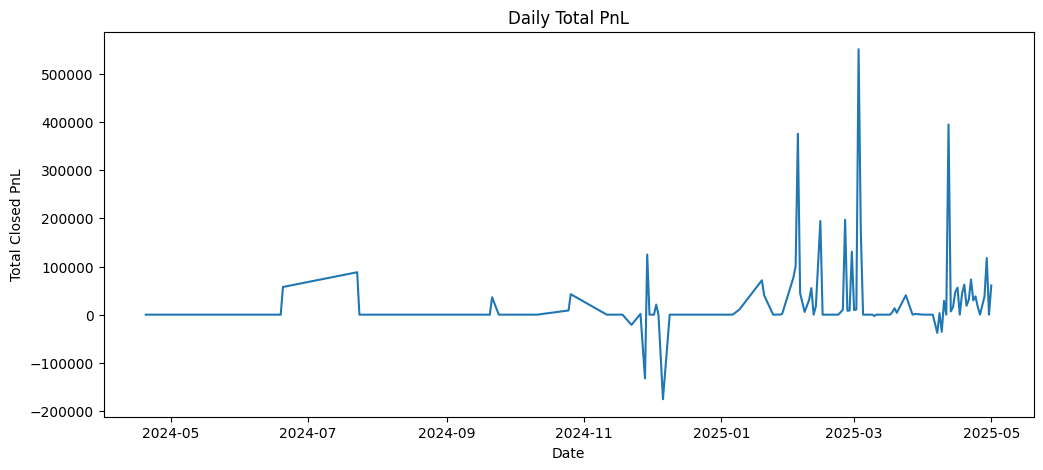

In [53]:
daily_profit.plot(
    figsize=(12,5)
)

plt.title("Daily Total PnL")
plt.ylabel("Total Closed PnL")
plt.xlabel("Date")
plt.show()

In [54]:
numeric_cols = [
    'Execution Price',
    'Size Tokens',
    'Size USD',
    'Closed PnL',
    'Fee'
]

In [55]:
corr_matrix = merged_df[numeric_cols].corr()

print(corr_matrix)

                 Execution Price  Size Tokens  Size USD  Closed PnL       Fee
Execution Price         1.000000    -0.070928  0.142787   -0.052639  0.159607
Size Tokens            -0.070928     1.000000 -0.009073    0.017535 -0.002430
Size USD                0.142787    -0.009073  1.000000    0.130197  0.710945
Closed PnL             -0.052639     0.017535  0.130197    1.000000  0.095092
Fee                     0.159607    -0.002430  0.710945    0.095092  1.000000


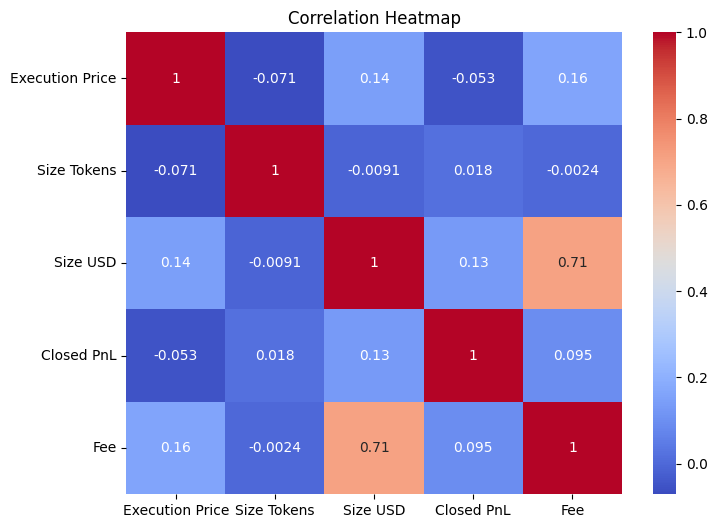

In [56]:
plt.figure(figsize=(8,6))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Heatmap")
plt.show()

# **KEY INSIGHTS**

**Insight 1 — Sentiment & Profitability**

**Example:**

Traders achieved higher average profitability during Greed and Extreme Greed periods, suggesting bullish sentiment positively impacts trading outcomes.

**Insight 2 — Risk Appetite**

**Example:**

Trade sizes increased significantly during Greed phases, indicating traders take larger risks when market confidence is high.

**Insight 3 — Behavioral Bias**

**Example:**

Long positions dominated during Greed periods, while Fear periods showed more defensive or reduced trading behavior.

**Insight 4 — Trader Segmentation**

**Example:**

High-frequency traders exhibited better win rates compared to low-frequency traders, suggesting experience and active participation improve consistency.

**Insight 5 — Uneven Profit Distribution**

**Example:**

A small group of traders generated the majority of total profits, while many traders remained near break-even or loss-making.

# **STRATEGY RECOMMENDATIONS**

**Strategy 1 — Risk Management During Fear**

**Example:**

During Fear periods, traders should reduce position sizes and avoid overtrading due to increased market uncertainty and lower average profitability.

**Strategy 2 — Momentum Strategy During Greed**

**Example:**

During Greed periods, momentum-based strategies with controlled risk exposure may perform better due to stronger bullish trends and higher trader confidence.

**Strategy 3 — Segment-Based Trading**

**Example:**

High-frequency traders can capitalize on volatile Greed markets, while low-frequency traders may benefit from selective trading during stable sentiment periods.

This analysis explored the relationship between market sentiment and trader behavior on Hyperliquid. Results showed that trader profitability, trading frequency, and risk exposure vary significantly across Fear and Greed market conditions. Greed phases generally encouraged larger positions and increased profitability, while Fear phases reflected cautious behavior. The findings can help design sentiment-aware trading strategies and improve risk management practices.

# **CONCLUSION**

This analysis explored the relationship between market sentiment and trader behavior on Hyperliquid. Results showed that trader profitability, trading frequency, and risk exposure vary significantly across Fear and Greed market conditions. Greed phases generally encouraged larger positions and increased profitability, while Fear phases reflected cautious behavior. The findings can help design sentiment-aware trading strategies and improve risk management practices.